In [1]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import lightgbm as lgb

from config import TRAIN_DATA_PATH

warnings.filterwarnings('ignore', category=FutureWarning)  # tắt deprecation SVC(probability=True)

SEED = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## 1. Load Data

In [2]:
df = pd.read_csv(TRAIN_DATA_PATH, index_col=0)
print(f'Shape: {df.shape}')
print(f'Target distribution:\n{df["player_result"].value_counts()}')
df.head()

Shape: (1284, 8)
Target distribution:
player_result
Win     610
Loss    592
Draw     82
Name: count, dtype: int64


,rating_diff,num_moves,duration (seconds),avg_time_per_move,opponent_rating,time_from_the_last_game,player_color,player_result
0,-281,63,336.0,5.226667,1374,NaN,black,Loss
1,139,39,515.0,12.436842,1078,56121.633333,white,Win
2,106,70,773.0,17.250000,1202,0.216667,black,Win
3,77,75,813.0,10.664865,1306,5752.150000,white,Win
4,-8,45,562.0,14.976190,1316,0.200000,black,Loss


## 2. Preprocessing

In [3]:
df_clean = df.copy()

# Điền NaN bằng median
df_clean['time_from_the_last_game'] = df_clean['time_from_the_last_game'].fillna(
    df_clean['time_from_the_last_game'].median()
)

# Encode player_color: white=1, black=0
df_clean['player_color'] = (df_clean['player_color'].str.lower() == 'white').astype(int)

# Binary target: Win=1, Not Win (Draw + Loss)=0
df_clean['target'] = (df_clean['player_result'].str.lower() == 'win').astype(int)

FEATURES = [c for c in df_clean.columns if c not in ('player_result', 'target')]
X = df_clean[FEATURES]
y = df_clean['target']

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'NaN remaining: {X.isna().sum().sum()}')
print(f'\nTarget distribution:')
print(y.value_counts().rename({1: 'Win', 0: 'Not Win (Draw + Loss)'}))
print(f'Class balance: {y.mean():.2%} Win')

Features (7): ['rating_diff', 'num_moves', 'duration (seconds)', 'avg_time_per_move', 'opponent_rating', 'time_from_the_last_game', 'player_color']
NaN remaining: 0

Target distribution:
target
Not Win (Draw + Loss)    674
Win                      610
Name: count, dtype: int64
Class balance: 47.51% Win


## 3. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train Win rate: {y_train.mean():.2%}  |  Test Win rate: {y_test.mean():.2%}')

Train: (1027, 7)  |  Test: (257, 7)
Train Win rate: 47.52%  |  Test Win rate: 47.47%


## 4. Model Training & Cross-Validation Comparison

In [5]:
def roc_auc_proba(estimator, X, y):
    """ROC AUC dùng xác suất lớp dương (cột 1).

    sklearn 1.9 + xgboost 2.1.3 lệch phiên bản: scorer 'roc_auc' dạng chuỗi không
    tự lát cột proba cho XGBoost -> truyền nguyên mảng (n, 2) vào roc_auc_score
    -> AUC = nan. Tự lát [:, 1] ở đây để mọi model đều tính đúng.
    """
    return roc_auc_score(y, estimator.predict_proba(X)[:, 1])


scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': roc_auc_proba}

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=11)),
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=SEED)),
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=SEED),
    'XGBoost': xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', early_stopping_rounds=None,
        random_state=SEED, verbosity=0,
    ),
    'LightGBM': lgb.LGBMClassifier(
        objective='binary',
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbose=-1,
    ),
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=CV,
        scoring=scoring,
        return_train_score=False,
    )
    cv_results[name] = {
        'Accuracy':  scores['test_accuracy'].mean(),
        'Accuracy±': scores['test_accuracy'].std(),
        'F1':        scores['test_f1'].mean(),
        'F1±':       scores['test_f1'].std(),
        'ROC AUC':   scores['test_roc_auc'].mean(),
        'ROC AUC±':  scores['test_roc_auc'].std(),
    }
    print(f'{name:<22} acc={scores["test_accuracy"].mean():.4f}  f1={scores["test_f1"].mean():.4f}  auc={scores["test_roc_auc"].mean():.4f}')

Logistic Regression    acc=0.7539  f1=0.7403  auc=0.8116
KNN                    acc=0.7150  f1=0.6930  auc=0.7703
SVM                    acc=0.8014  f1=0.7914  auc=0.8695
Random Forest          acc=0.8177  f1=0.8060  auc=0.9036
XGBoost                acc=0.8209  f1=0.8129  auc=0.9108
LightGBM               acc=0.8201  f1=0.8124  auc=0.9122


## 5. Comparison Table

In [6]:
df_cv = pd.DataFrame(cv_results).T
df_cv['Accuracy (mean±std)'] = df_cv.apply(lambda r: f"{r['Accuracy']:.4f} ± {r['Accuracy±']:.4f}", axis=1)
df_cv['F1 (mean±std)']       = df_cv.apply(lambda r: f"{r['F1']:.4f} ± {r['F1±']:.4f}", axis=1)
df_cv['ROC AUC (mean±std)']  = df_cv.apply(lambda r: f"{r['ROC AUC']:.4f} ± {r['ROC AUC±']:.4f}", axis=1)

summary = df_cv[['Accuracy (mean±std)', 'F1 (mean±std)', 'ROC AUC (mean±std)']].copy()
summary.index.name = 'Model'
summary = summary.sort_values('Accuracy (mean±std)', ascending=False)

# Highlight best per metric
display(summary.style.highlight_max(
    subset=['Accuracy (mean±std)', 'F1 (mean±std)', 'ROC AUC (mean±std)'],
    color='#d4edda'
))

,Accuracy (mean±std),F1 (mean±std),ROC AUC (mean±std)
Model,,,
XGBoost,0.8209 ± 0.0193,0.8129 ± 0.0185,0.9108 ± 0.0101
LightGBM,0.8201 ± 0.0150,0.8124 ± 0.0139,0.9122 ± 0.0102
Random Forest,0.8177 ± 0.0093,0.8060 ± 0.0066,0.9036 ± 0.0094
SVM,0.8014 ± 0.0203,0.7914 ± 0.0249,0.8695 ± 0.0096
Logistic Regression,0.7539 ± 0.0265,0.7403 ± 0.0332,0.8116 ± 0.0149
KNN,0.7150 ± 0.0371,0.6930 ± 0.0496,0.7703 ± 0.0233


## 6. Confusion Matrix (Top 2 Models on Test Set

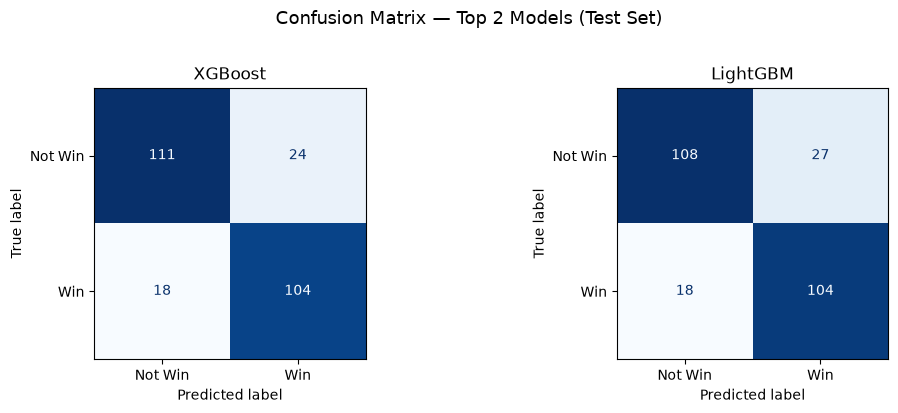

In [7]:
# Lấy 2 model có accuracy CV cao nhất
top2 = df_cv['Accuracy'].nlargest(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, top2):
    model = models[name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Win', 'Win'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=12)

plt.suptitle('Confusion Matrix — Top 2 Models (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Importance (Tree Models)

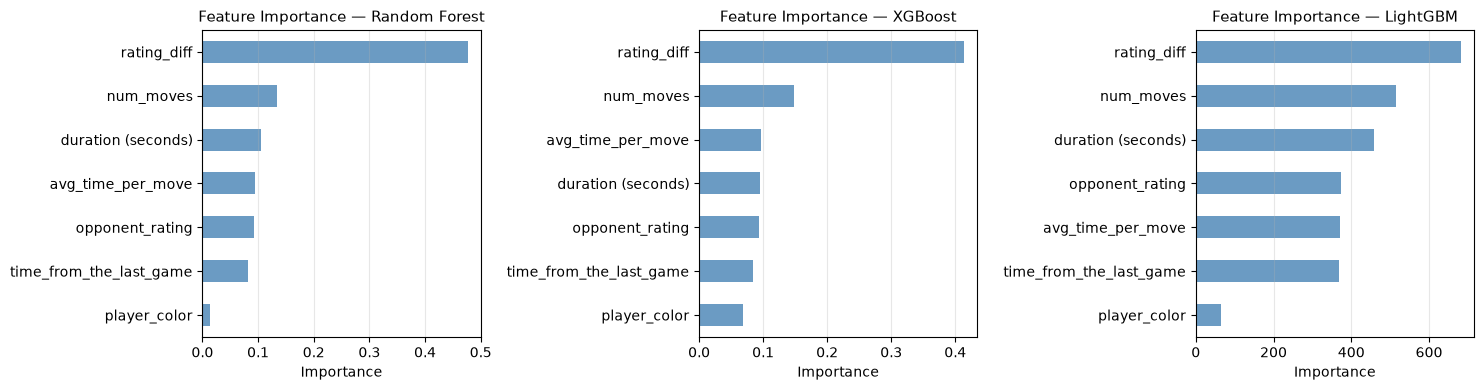

In [8]:
tree_models = ['Random Forest', 'XGBoost', 'LightGBM']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, tree_models):
    model = models[name]
    model.fit(X_train, y_train)
    importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importance.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(f'Feature Importance — {name}', fontsize=11)
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Classification Report — Top Model

In [9]:
best_name = df_cv['Accuracy'].idxmax()
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f'Best model: {best_name}')
print(classification_report(y_test, y_pred_best, target_names=['Not Win', 'Win']))

Best model: XGBoost
              precision    recall  f1-score   support

     Not Win       0.86      0.82      0.84       135
         Win       0.81      0.85      0.83       122

    accuracy                           0.84       257
   macro avg       0.84      0.84      0.84       257
weighted avg       0.84      0.84      0.84       257



## 9. Retrain với Top 3 Features

=== XGBoost (top 3 features) ===
              precision    recall  f1-score   support

     Not Win       0.84      0.81      0.82       135
         Win       0.80      0.83      0.81       122

    accuracy                           0.82       257
   macro avg       0.82      0.82      0.82       257
weighted avg       0.82      0.82      0.82       257



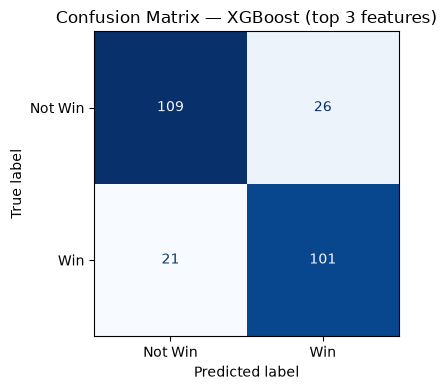

In [14]:
top3 = ['rating_diff', 'num_moves', 'duration (seconds)']

X_train_top3 = X_train[top3]
X_test_top3  = X_test[top3]

# Lấy model xếp hạng cao nhất ở bảng so sánh (theo Accuracy CV) thay vì hardcode XGBoost.
best_name = df_cv['Accuracy'].idxmax()
top3_model = clone(models[best_name])   # clone -> fit lại từ đầu chỉ trên top-3 features
top3_model.fit(X_train_top3, y_train)
y_pred_top3 = top3_model.predict(X_test_top3)

print(f'=== {best_name} (top 3 features) ===')
print(classification_report(y_test, y_pred_top3, target_names=['Not Win', 'Win']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_top3, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['Not Win', 'Win']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (top 3 features)', fontsize=12)
plt.tight_layout()
plt.show()